# Linear Fixed-Parameter Experiment (`k=0`)

論文と同じ線形回帰タスク設定（有限 `M`）で、
**訓練時 CoT なし (`k=0`)** のときの学習済み更新行列 `A*` を求め、
推論反復回数 `t` に対する汎化誤差
\(\mathcal{E}_{0,t} = \frac{1}{D}\mathbb{E}[\|w-\hat w_t\|^2]\)
をプロットする。

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 固定パラメータ（paper_reproduce_finiteM.ipynb に合わせる） =====
SEED = 42
D = 20
L = 30
M = 400
LAMBDA = 0.1
SIGMA_TRAIN = 0.0  # 訓練タスクのラベルノイズ標準偏差

# 評価設定
T_MAX = 20
N_PRETRAIN_REPEATS = 20
N_TEST_TASKS = 2000

rng = np.random.default_rng(SEED)
print(f"D={D}, L={L}, M={M}, lambda={LAMBDA}, sigma_train={SIGMA_TRAIN}")
print(f"t_max={T_MAX}, repeats={N_PRETRAIN_REPEATS}, n_test={N_TEST_TASKS}")

D=20, L=30, M=400, lambda=0.1, sigma_train=0.0
t_max=20, repeats=20, n_test=2000


In [43]:
def sample_tasks(M, D, L, sigma, rng):
    """訓練タスクを M 個サンプルする。"""
    X = rng.normal(0.0, 1.0 / np.sqrt(D), size=(M, D, L))
    w = rng.normal(0.0, 1.0, size=(M, D))
    eps = rng.normal(0.0, sigma, size=(M, L)) if sigma > 0 else np.zeros((M, L))
    y = np.einsum("md,mdl->ml", w, X) + eps
    return X, y, w


def fit_A_star_k0(X, y, w, lam):
    """k=0 の ridge ERM から A* を閉形式で計算する。"""
    M, D, L = X.shape
    g = (D / L) * np.einsum("mdl,ml->md", X, y)  # g_mu = (D/L) X_mu y_mu

    G = g.T  # [D, M]
    W = w.T  # [D, M]
    reg = (M * lam / 2.0) * np.eye(D)

    # A* = W G^T (G G^T + (M*lam/2)I)^{-1}
    A_star = (W @ G.T) @ np.linalg.solve(G @ G.T + reg, np.eye(D))
    return A_star


def generalization_curve_for_A(A, D, L, t_max, n_test, rng):
    """学習済み A を固定し、推論反復 t ごとの汎化誤差を返す。"""
    X = rng.normal(0.0, 1.0 / np.sqrt(D), size=(n_test, D, L))
    w = rng.normal(0.0, 1.0, size=(n_test, D))
    y = np.einsum("md,mdl->ml", w, X)  # inference は noiseless

    S = X @ np.transpose(X, (0, 2, 1))
    b = np.einsum("mdl,ml->md", X, y)

    w_hat = np.zeros((n_test, D))
    errs = np.empty(t_max + 1)
    errs[0] = np.mean(np.sum((w - w_hat) ** 2, axis=1) / D)

    for t in range(1, t_max + 1):
        grad = np.einsum("mde,me->md", S, w_hat) - b
        w_hat = w_hat - (D / L) * (grad @ A.T)
        errs[t] = np.mean(np.sum((w - w_hat) ** 2, axis=1) / D)

    return errs


def estimate_E0t(D, L, M, lam, sigma_train, t_max, n_pretrain_repeats, n_test, seed):
    """pre-train 乱数も含めて E_{0,t} を Monte Carlo 推定する。"""
    all_curves = np.empty((n_pretrain_repeats, t_max + 1))

    for r in range(n_pretrain_repeats):
        rng_r = np.random.default_rng(seed + 1000 * r)

        # pre-training (k=0)
        X_tr, y_tr, w_tr = sample_tasks(M, D, L, sigma_train, rng_r)
        A_star = fit_A_star_k0(X_tr, y_tr, w_tr, lam)

        # inference generalization
        all_curves[r] = generalization_curve_for_A(A_star, D, L, t_max, n_test, rng_r)

    mean_curve = all_curves.mean(axis=0)
    std_curve = all_curves.std(axis=0)
    return mean_curve, std_curve

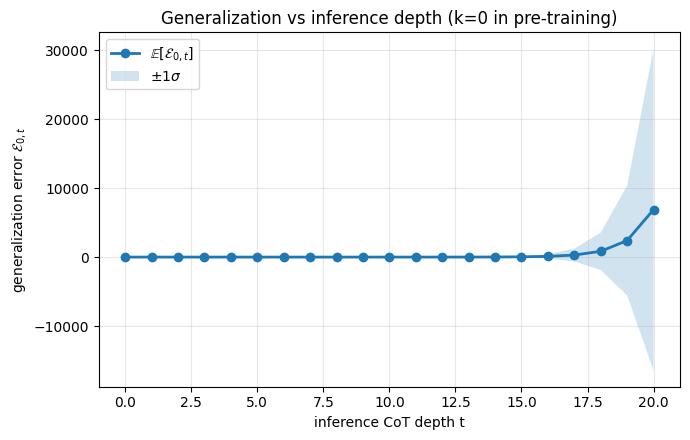

t= 0, E_0,t=0.999292
t= 1, E_0,t=0.433731
t= 2, E_0,t=0.282131
t= 3, E_0,t=0.214952
t= 4, E_0,t=0.173366
t= 5, E_0,t=0.149026
t= 6, E_0,t=0.134766
t= 7, E_0,t=0.133620
t= 8, E_0,t=0.151458
t= 9, E_0,t=0.211928
t=10, E_0,t=0.373395
t=11, E_0,t=0.799100
t=12, E_0,t=1.931336
t=13, E_0,t=5.006944
t=14, E_0,t=13.494759
t=15, E_0,t=37.233172
t=16, E_0,t=104.248195
t=17, E_0,t=294.788583
t=18, E_0,t=839.340266
t=19, E_0,t=2401.776359
t=20, E_0,t=6898.195212


In [44]:
E_mean, E_std = estimate_E0t(
    D=D,
    L=L,
    M=M,
    lam=LAMBDA,
    sigma_train=SIGMA_TRAIN,
    t_max=T_MAX,
    n_pretrain_repeats=N_PRETRAIN_REPEATS,
    n_test=N_TEST_TASKS,
    seed=SEED,
)

ts = np.arange(T_MAX + 1)

plt.figure(figsize=(7, 4.5))
plt.plot(ts, E_mean, marker="o", linewidth=2, label=r"$\mathbb{E}[\mathcal{E}_{0,t}]$")
plt.fill_between(ts, E_mean - E_std, E_mean + E_std, alpha=0.2, label=r"$\pm 1\sigma$")
plt.xlabel("inference CoT depth t")
plt.ylabel(r"generalization error $\mathcal{E}_{0,t}$")
plt.title("Generalization vs inference depth (k=0 in pre-training)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for t, e in zip(ts, E_mean):
    print(f"t={t:2d}, E_0,t={e:.6f}")

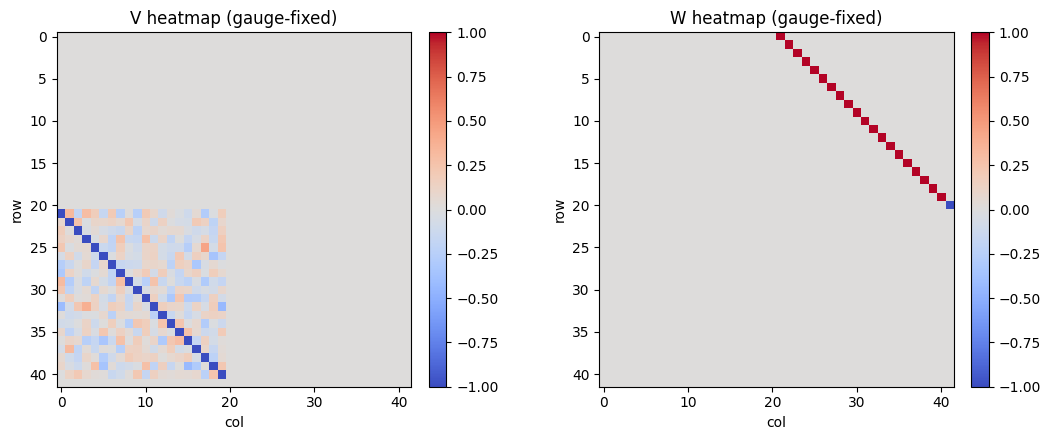

V shape = (42, 42), W shape = (42, 42)
||A*||_F = 2.603943
gauge scale c = 0.296636
product preservation ||V'W' - VW||_F = 3.602e-15
fixed heatmap range = [-1.0, 1.0]


In [45]:
# ===== 学習後パラメータ V, W の heatmap（k=0） =====
# V, W は cV, W/c のスケール同値性を持つので、可視化前に gauge-fix する。
# その上で色スケールを固定値にする。

HEATMAP_VMAX = 1.0  # 固定色スケール: [-HEATMAP_VMAX, HEATMAP_VMAX]

rng_vis = np.random.default_rng(SEED)
X_tr_vis, y_tr_vis, w_tr_vis = sample_tasks(M, D, L, SIGMA_TRAIN, rng_vis)
A_star_vis = fit_A_star_k0(X_tr_vis, y_tr_vis, w_tr_vis, LAMBDA)

DE = 2 * D + 2
W_vis = np.zeros((DE, DE))
V_vis = np.zeros((DE, DE))

# block size: (D, 1, D, 1)
# W = [[0,0,I,0],[0,0,0,-1],[0,0,0,0],[0,0,0,0]]
W_vis[0:D, D + 1 : D + 1 + D] = np.eye(D)
W_vis[D, -1] = -1.0

# V = [[0,0,0,0],[0,0,0,0],[-D*A,0,0,0],[0,0,0,0]]
V_vis[D + 1 : D + 1 + D, 0:D] = -D * A_star_vis

# gauge-fix: ||V||_F と ||W||_F を一致させるスケーリング
v_norm = np.linalg.norm(V_vis, ord="fro")
w_norm = np.linalg.norm(W_vis, ord="fro")
if v_norm > 0 and w_norm > 0:
    c = np.sqrt(w_norm / v_norm)
    V_plot = c * V_vis
    W_plot = W_vis / c
else:
    c = 1.0
    V_plot = V_vis.copy()
    W_plot = W_vis.copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axes[0].imshow(V_plot, cmap="coolwarm", vmin=-HEATMAP_VMAX, vmax=HEATMAP_VMAX)
axes[0].set_title("V heatmap (gauge-fixed)")
axes[0].set_xlabel("col")
axes[0].set_ylabel("row")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(W_plot, cmap="coolwarm", vmin=-HEATMAP_VMAX, vmax=HEATMAP_VMAX)
axes[1].set_title("W heatmap (gauge-fixed)")
axes[1].set_xlabel("col")
axes[1].set_ylabel("row")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

prod_err = np.linalg.norm(V_plot @ W_plot - V_vis @ W_vis, ord="fro")
print(f"V shape = {V_vis.shape}, W shape = {W_vis.shape}")
print(f"||A*||_F = {np.linalg.norm(A_star_vis):.6f}")
print(f"gauge scale c = {c:.6f}")
print(f"product preservation ||V'W' - VW||_F = {prod_err:.3e}")
print(f"fixed heatmap range = [{-HEATMAP_VMAX:.1f}, {HEATMAP_VMAX:.1f}]")